## K562, H3K27ac test set, bpnet architecture


## ENCSR000AKP

In [1]:
import h5py 

In [2]:
f=h5py.File("preds.hdf5.predictions",'r')

In [3]:
labels_0=f['lab_0'][:]
labels_1=f['lab_1'][:]
pred_0=f['pred_0'][:]
pred_1=f['pred_1'][:]
coord=f['coords'][:]

In [4]:
labels_0.shape

(52404, 1000, 2)

In [5]:
coord_fixed=[[i.decode('utf8')  for i in j] for j in coord]

In [6]:
outf=open("tmp.txt",'w')
for entry in coord_fixed: 
    outf.write(str(entry)+'\n')
outf.close()

In [7]:
coord_dict={} 
for i in range(len(coord_fixed)): 
    coord_dict[tuple(coord_fixed[i])]=i

In [8]:
import pandas as pd 
from scipy.stats import spearmanr 
from scipy.stats import pearsonr 
from scipy.special import softmax

## get ranked list of IDR peaks on chrom 1 (test chrom)

In [9]:
idr_peaks=pd.read_csv('../test.set.0.sorted.bed',header=None,sep='\t')
idr_peaks['summit']=idr_peaks[1]+idr_peaks[9]
idr_peaks=idr_peaks.sort_values(by=[8],ascending=False)
positions=[]
top_peaks=20
count=0
for index,row in idr_peaks.iterrows(): 
    summit=row['summit']
    chrom=row[0]
    count+=1
    if count >top_peaks: 
        break
    positions.append((chrom,str(summit),'.'))
        

In [10]:
idr_peaks.head()

,0,1,2,3,4,5,6,7,8,9,summit
0,chr1,44819761,44820994,Peak_2,1000,.,97.22496,537.88666,530.36877,361,44820122
1,chr1,156660266,156664254,Peak_3,1000,.,88.81126,480.34079,473.30157,289,156660555
2,chr1,36385995,36388381,Peak_4,1000,.,79.22759,479.27560,472.25146,903,36386898
3,chr1,114756267,114758689,Peak_24,1000,.,89.66182,444.94196,438.58255,1528,114757795
4,chr1,11907758,11910446,Peak_28,1000,.,80.04073,441.95123,435.63516,270,11908028


In [11]:
positions[0]

('chr1', '44820122', '.')

In [12]:
coord_dict[positions[0]]

4548

In [13]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5

In [14]:
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [15]:
labels_0[4548,:,0].shape

(1000,)

In [16]:
coord_fixed[4548]

['chr1', '44820122', '.']

In [17]:
import tiledb
f=tiledb.open("/srv/scratch/annashch/db_H3K27Ac/")

In [18]:
plus_vals=f[44820122-500:44820122+500,0]['count_bigwig_plus_5p']
minus_vals=f[44820122-500:44820122+500,0]['count_bigwig_minus_5p']

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


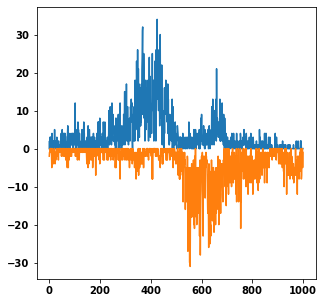

In [19]:
plt.rcParams["figure.figsize"]=5,5
plt.plot(plus_vals)
plt.plot(-1*minus_vals)

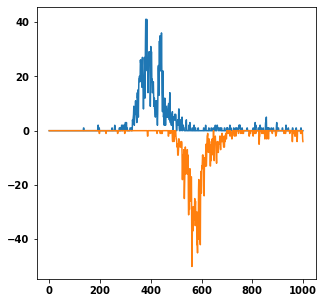

In [20]:
plt.plot(labels_0[4548,:,0])
plt.plot(-1*labels_0[4548,:,1])

In [21]:
pred_0_softmax=softmax(pred_0,axis=1)

In [22]:
pred_0_softmax.shape

(52404, 1000, 2)

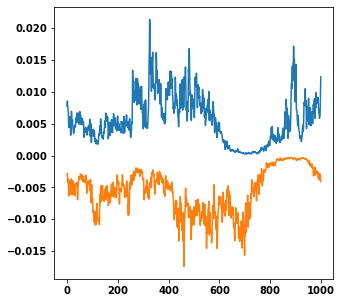

In [23]:
plt.plot(pred_0_softmax[0,:,0]*pred_1[0,0])
plt.plot(-1*pred_0_softmax[0,:,1]*pred_1[0,1])


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


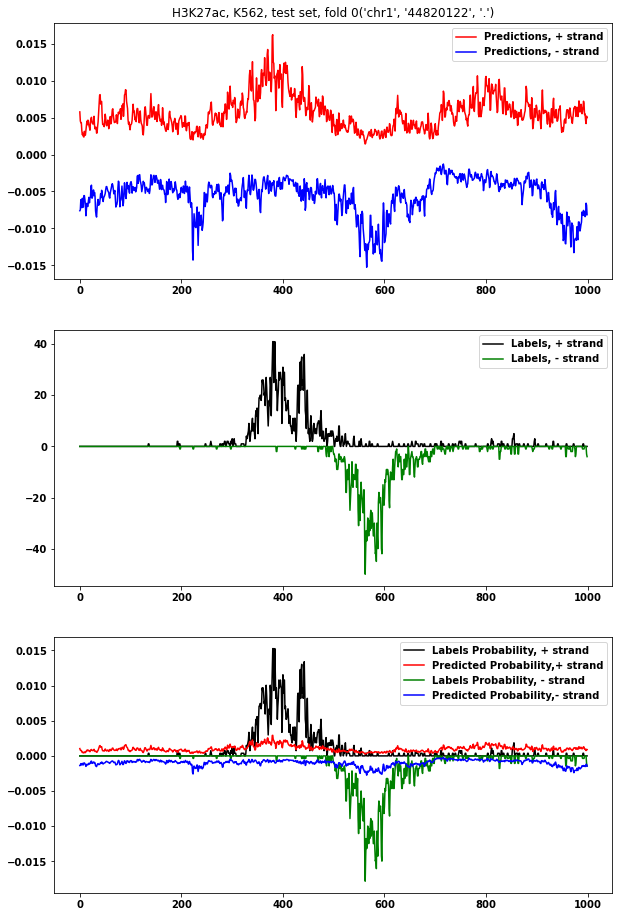

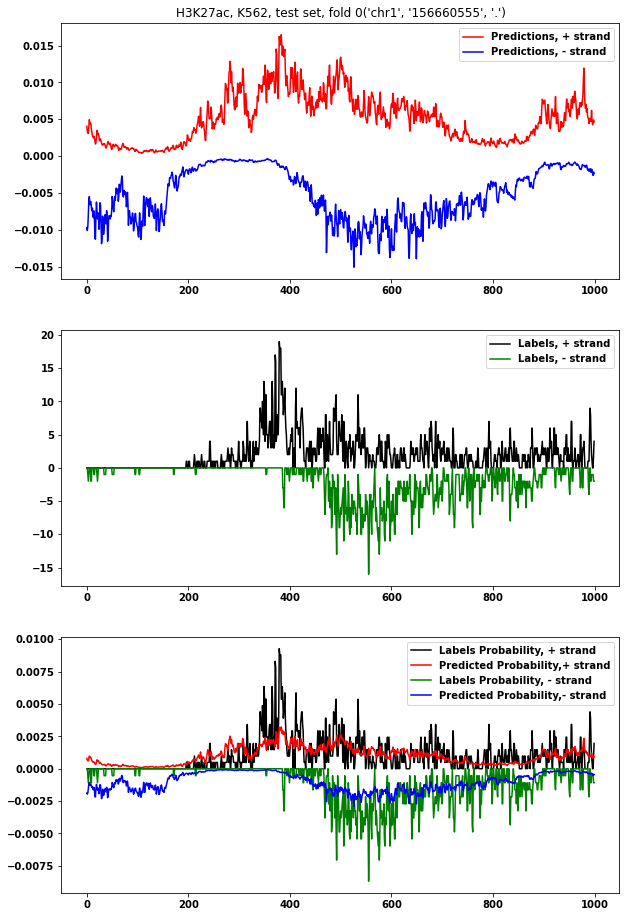

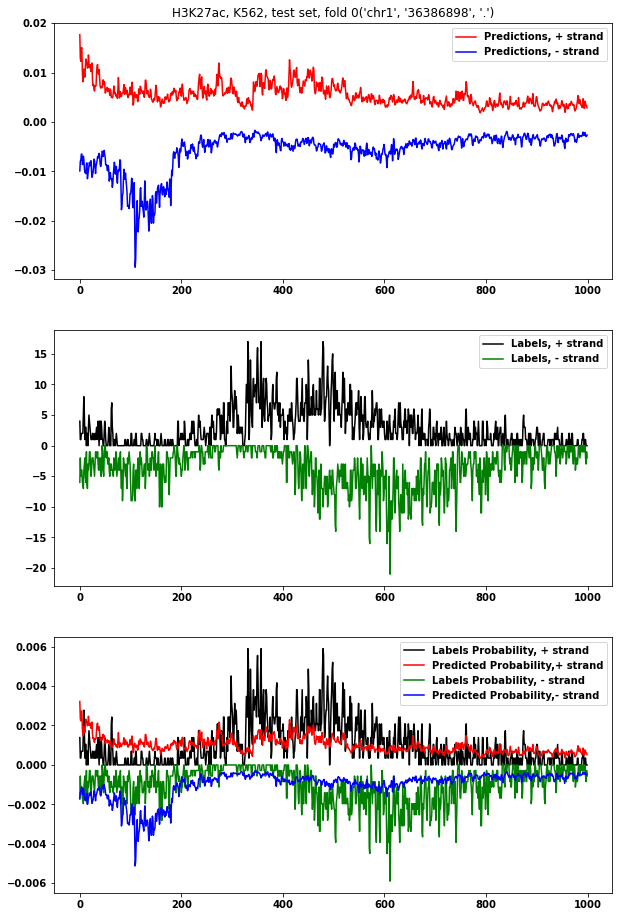

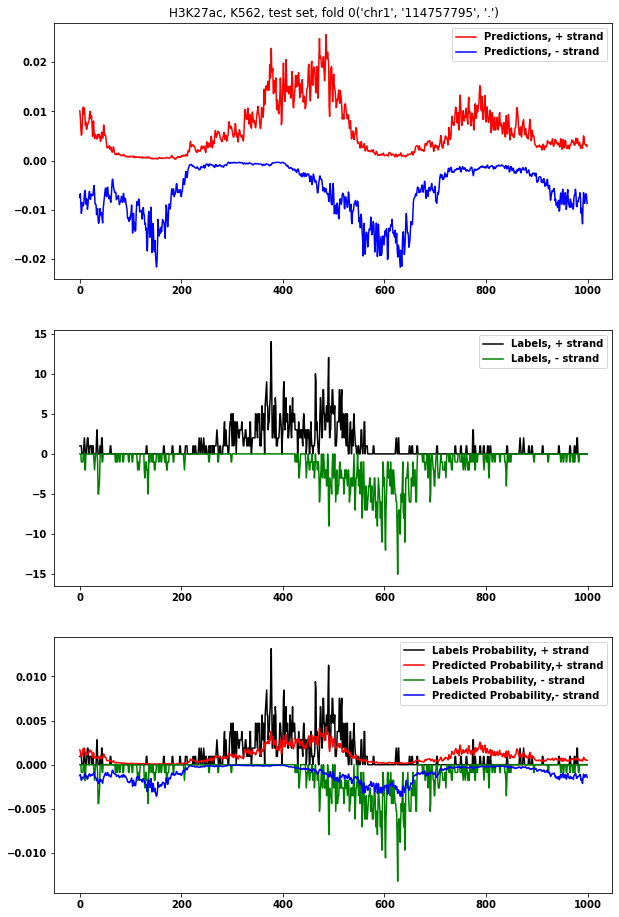

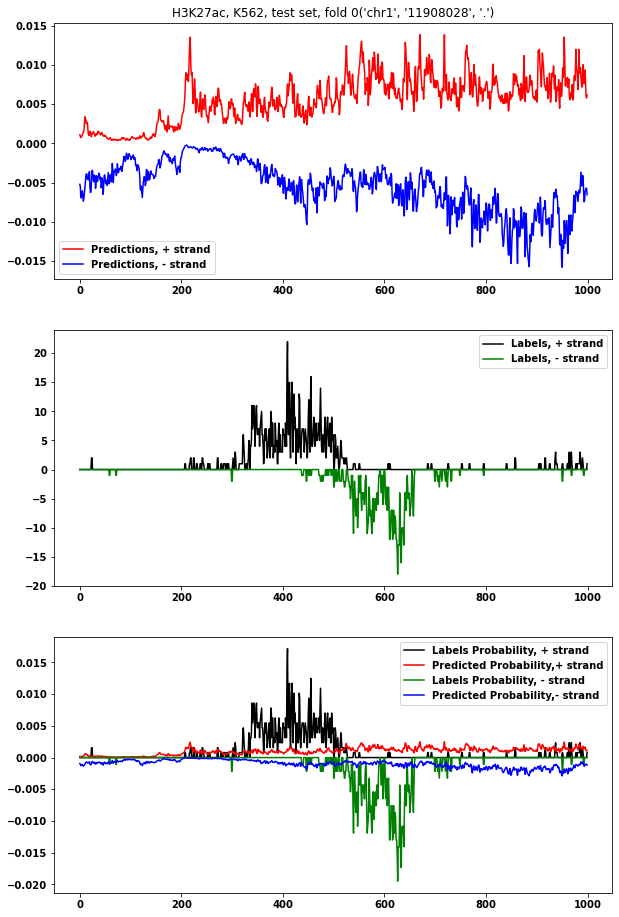

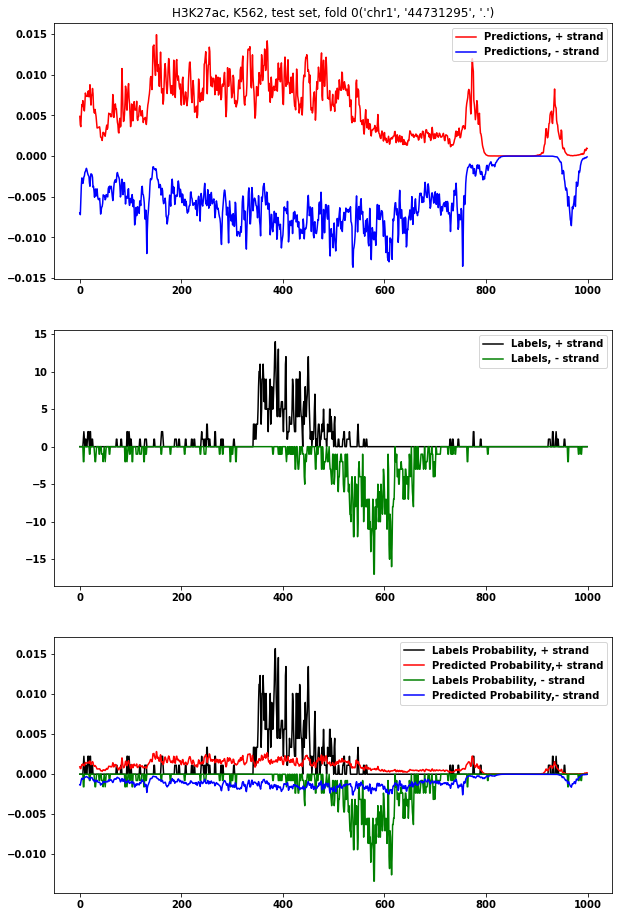

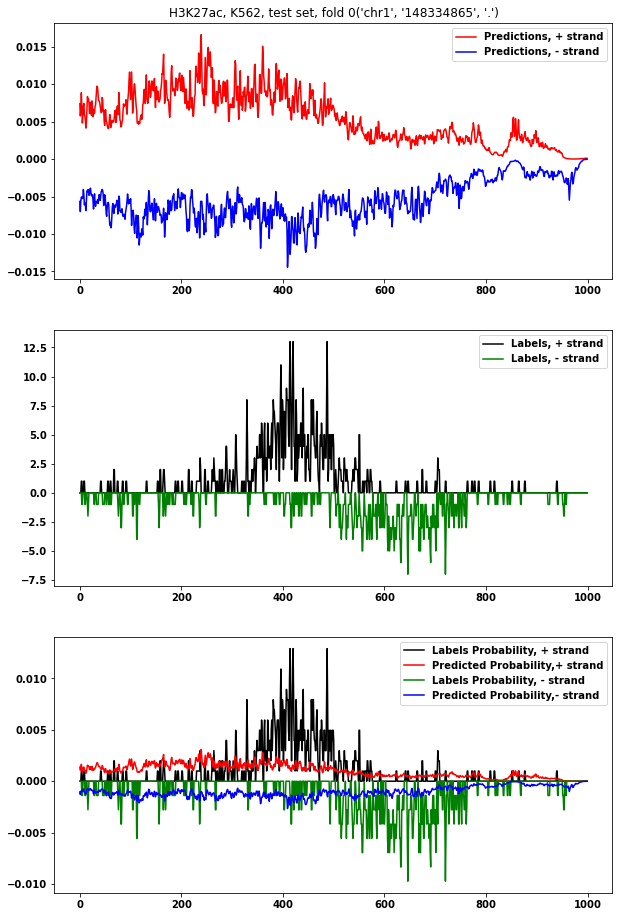

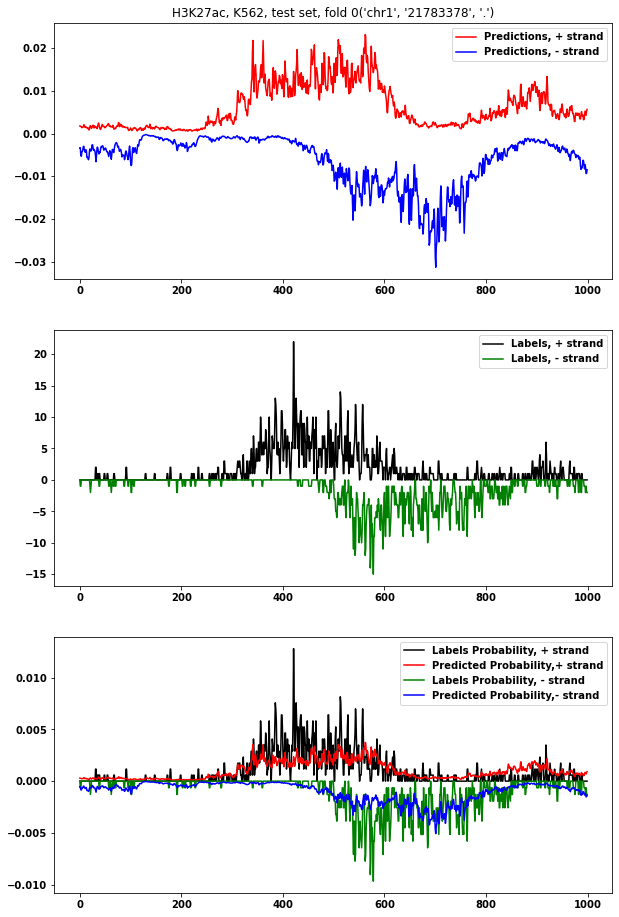

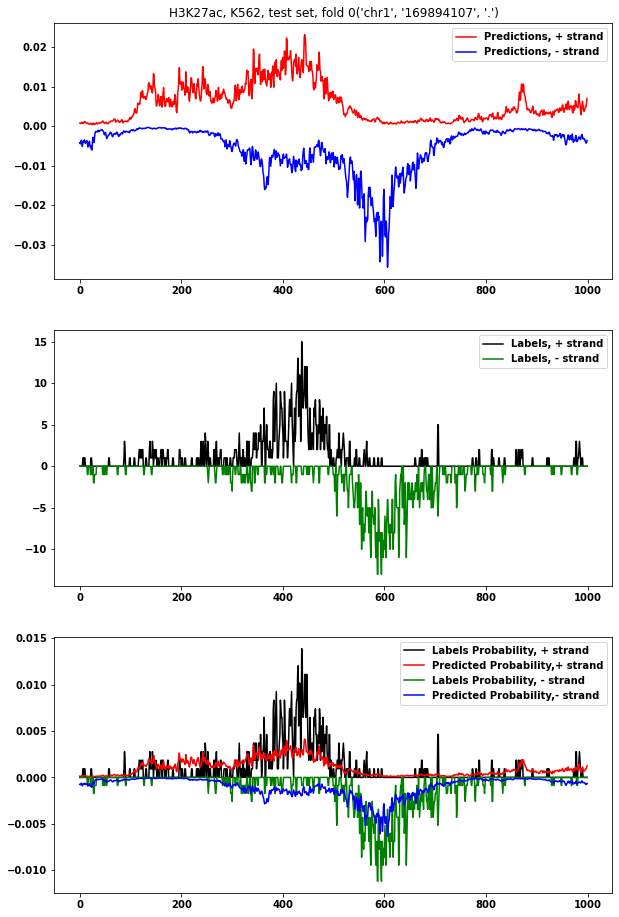

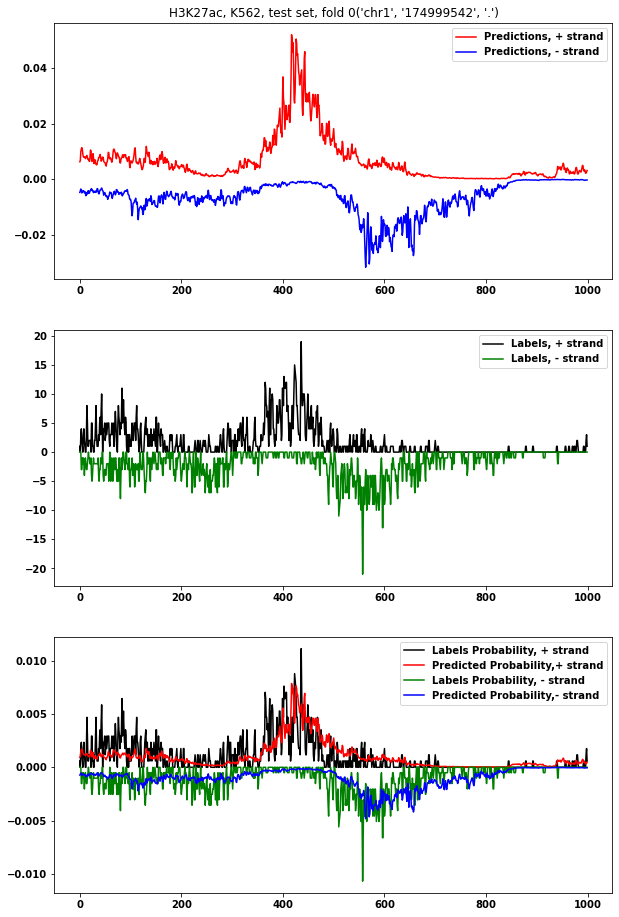

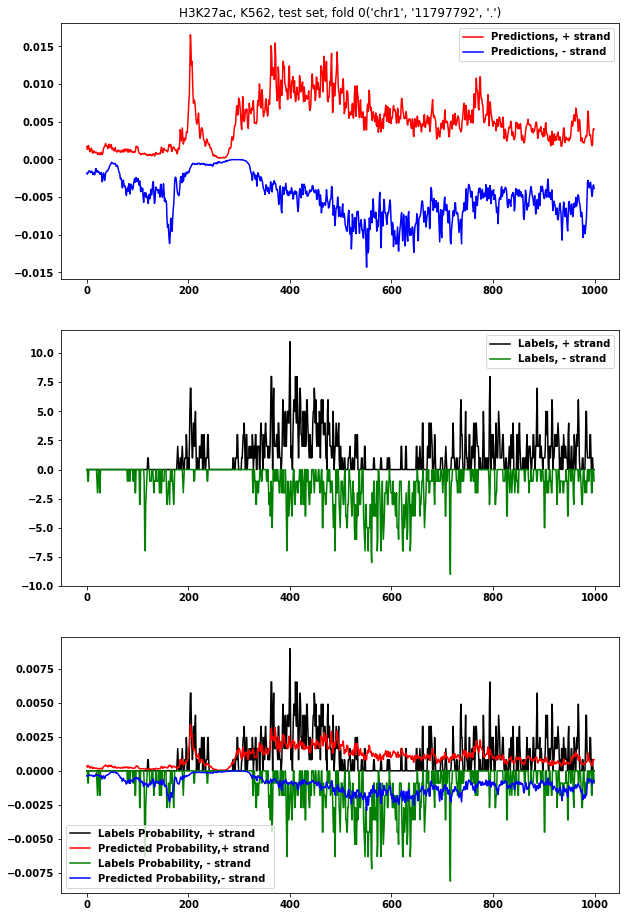

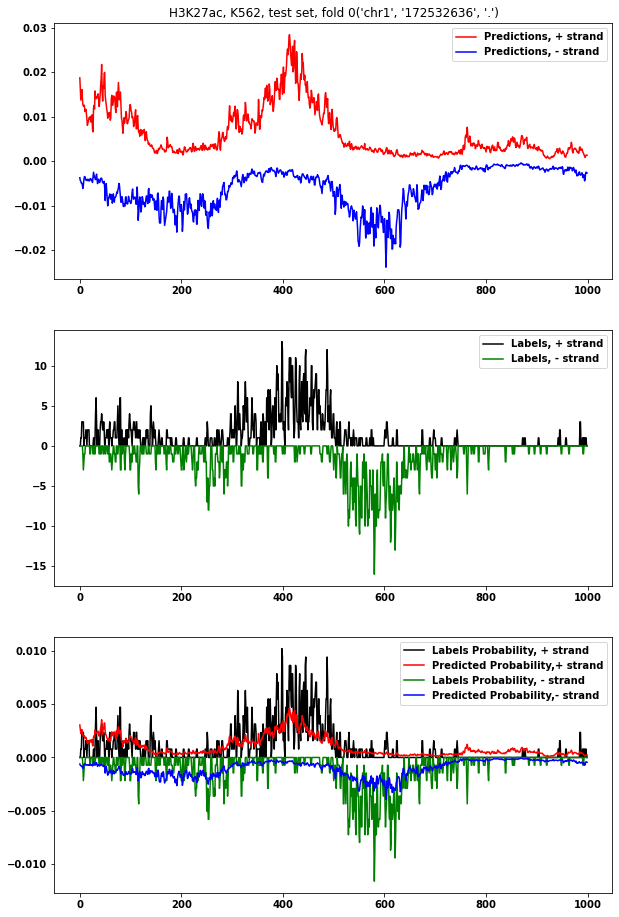

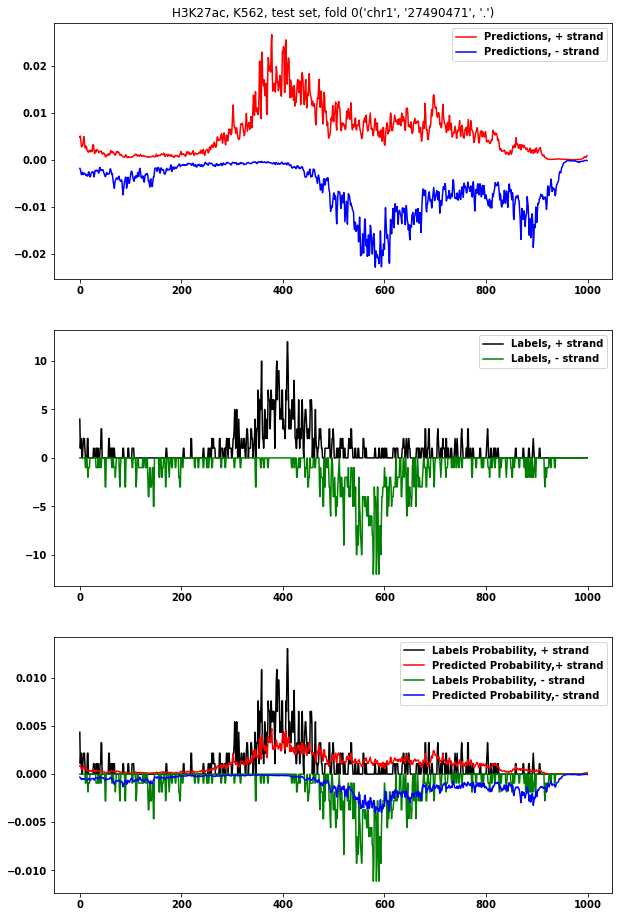

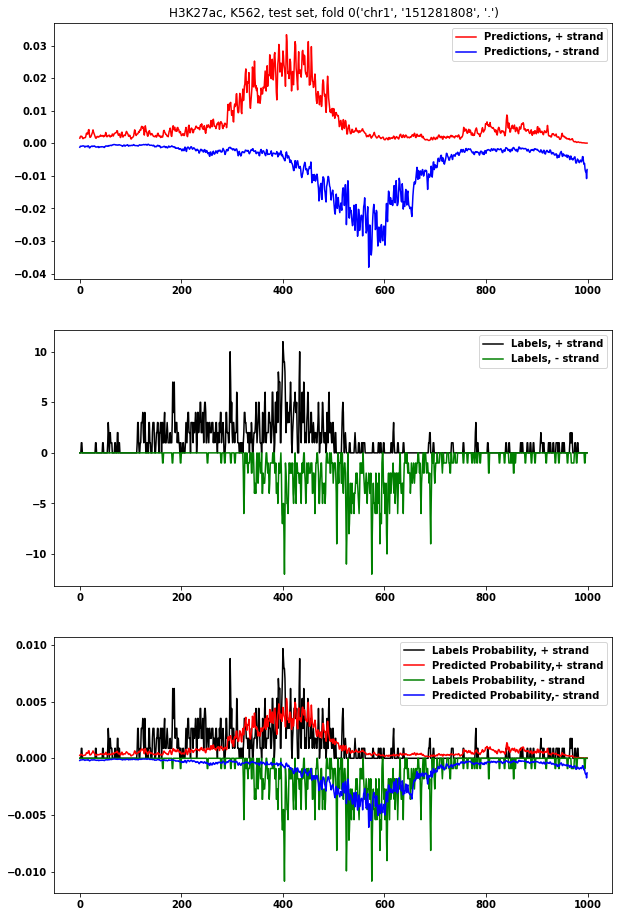

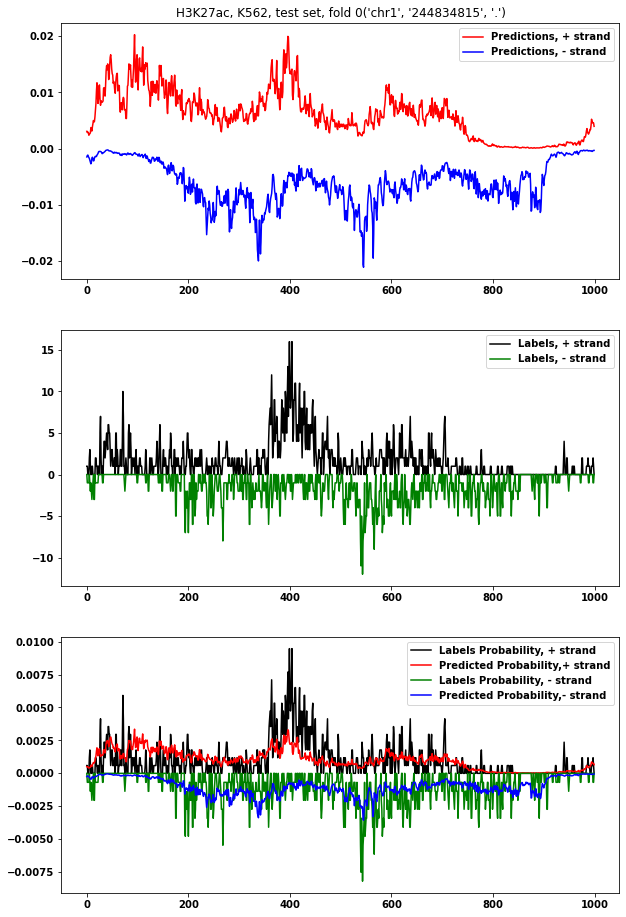

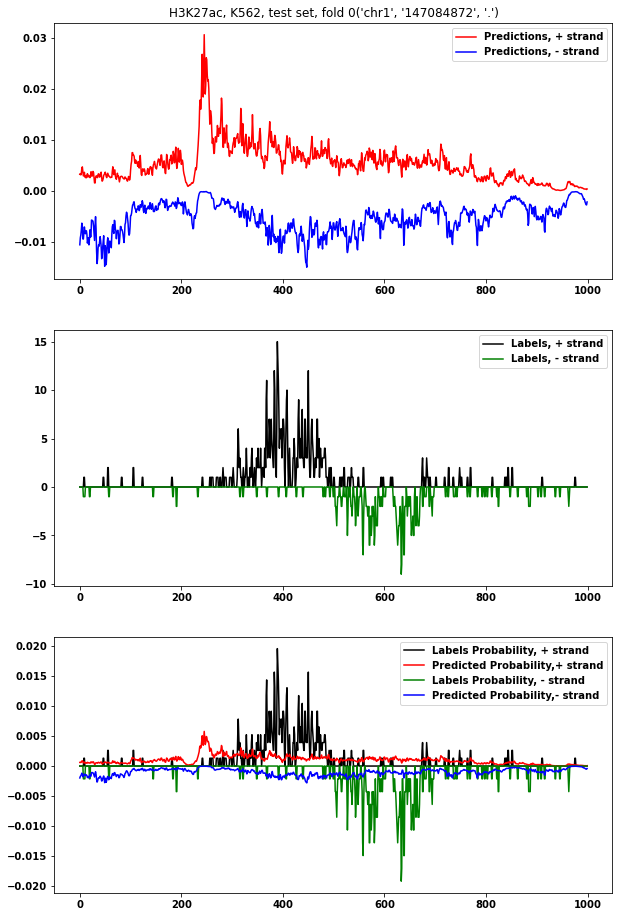

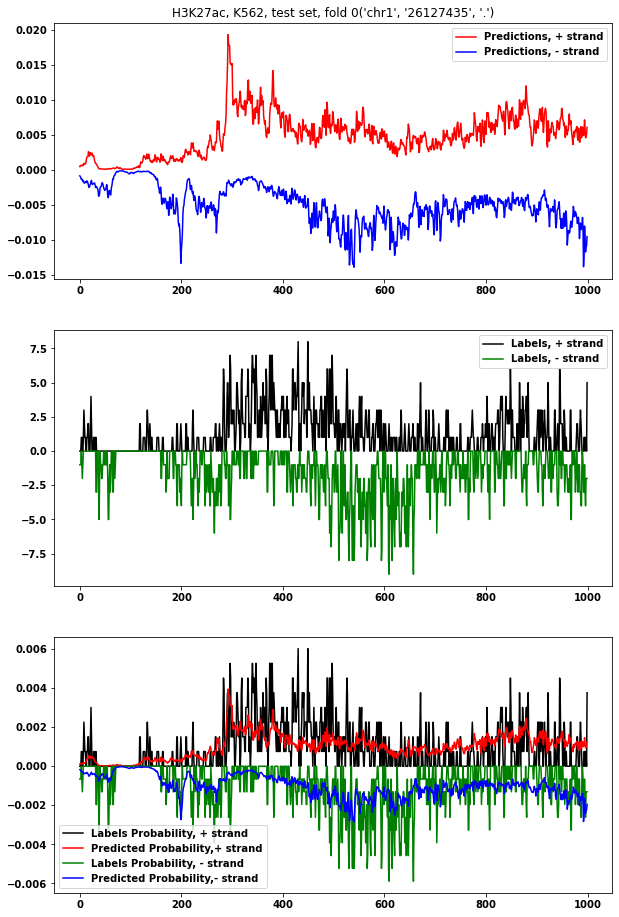

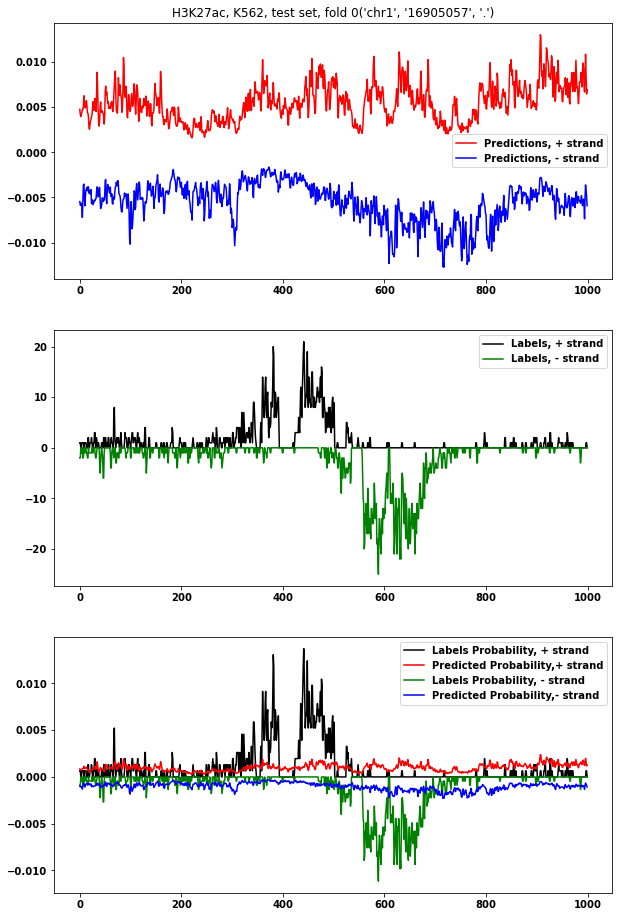

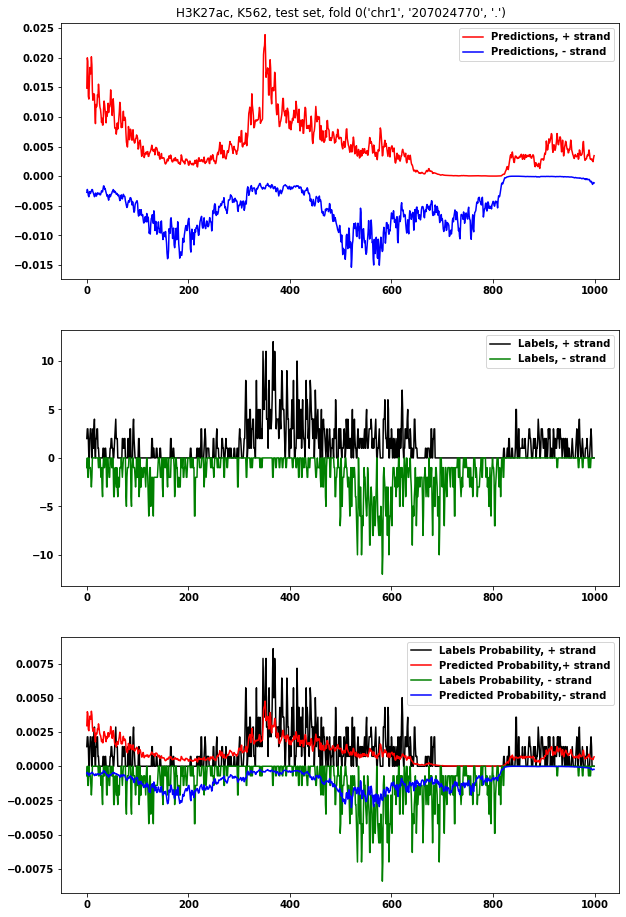

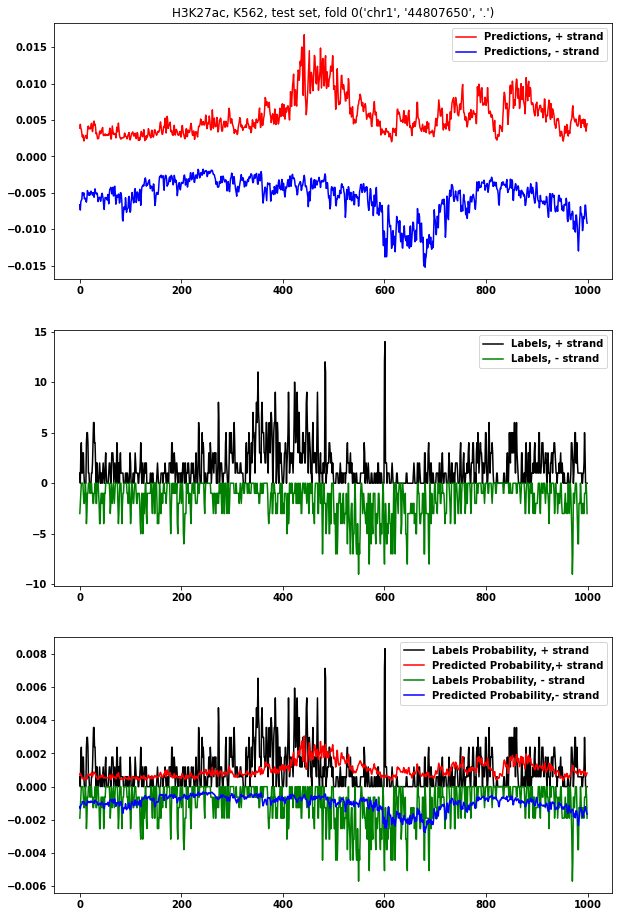

In [24]:
plt.rcParams["figure.figsize"]=10,16
title="H3K27ac, K562, test set, fold 0"
for pos in positions[0:20]: 
    cur_index=coord_dict[pos]
    counts_plus=pred_0_softmax[cur_index,:,0]*pred_1[cur_index,0]
    counts_minus=pred_0_softmax[cur_index,:,1]*pred_1[cur_index,1]
    prob_plus=pred_0_softmax[cur_index,:,0]
    prob_minus=pred_0_softmax[cur_index,:,1]
    fig, axes = plt.subplots(3, 1)
    probs_observed_forward=labels_0[cur_index,:,0]/sum(labels_0[cur_index,:,0])
    probs_observed_reverse=labels_0[cur_index,:,1]/sum(labels_0[cur_index,:,1])
    axes[0].plot(counts_plus,label='Predictions, + strand',color='r')
    axes[1].plot(labels_0[cur_index,:,0],label='Labels, + strand',color='k')
    axes[2].plot(probs_observed_forward,label="Labels Probability, + strand",color='k')
    axes[2].plot(pred_0_softmax[cur_index,:,0],label="Predicted Probability,+ strand",color='r')    
    axes[0].plot(-1*counts_minus,label='Predictions, - strand',color='b')
    axes[1].plot(-1*labels_0[cur_index,:,1],label='Labels, - strand',color='g')
    axes[2].plot(-1*probs_observed_reverse,label="Labels Probability, - strand",color='g')
    axes[2].plot(-1*pred_0_softmax[cur_index,:,1],label="Predicted Probability,- strand",color='b')            
    axes[0].set_title(title+str(pos))
    axes[0].legend()
    axes[1].legend() 
    axes[2].legend()
    plt.show() 
        


In [19]:
f.close()